# Softmax Regression
- Multi-class Classification

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [35]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [36]:
# encoding the categorical columns
gender_enc = LabelEncoder()
bp_enc = LabelEncoder()
chol_enc = LabelEncoder()
class_enc = LabelEncoder()

df['Gender'] = gender_enc.fit_transform(df['Gender'])
df['BloodPressure'] = bp_enc.fit_transform(df['BloodPressure'])
df['Cholestrol'] = chol_enc.fit_transform(df['Cholestrol'])
df['Class'] = class_enc.fit_transform(df['Class'])

In [37]:
# features and target
x = df.iloc[:,0:-1]
y = df.iloc[:, -1]

# split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [38]:
# hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'newton-cholesky'],
    'penalty': ['l2']
}

grid = GridSearchCV(estimator = LogisticRegression(),
                    param_grid = param_grid,
                    cv = 5,
                    scoring = 'accuracy',
                    n_jobs = -1)

grid.fit(x_train, y_train)

print('Best model : ',grid.best_estimator_)
print('Best Parameters : ',grid.best_params_)
print('Best score : ',grid.best_score_)

Best model :  LogisticRegression(C=10, solver='newton-cg')
Best Parameters :  {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
Best score :  0.9917808219178081


In [39]:
# feature Importance
best_model = grid.best_estimator_

# Coefficients can be used as a measure of feature importance for Logistic Regression
importance_df = pd.DataFrame({
    'feature' : x.columns,
    'importance' : abs(best_model.coef_[0]) # Assuming binary or one-vs-rest for multi-class
})

importance_df

,feature,importance
0,Age,0.184037
1,Gender,0.159214
2,BloodPressure,7.541320
3,Cholestrol,2.717325
4,Na_to_K,1.655661


> Keeping all features

In [40]:
# model train
best_model.fit(x_train, y_train)

LogisticRegression(C=10, solver='newton-cg')

In [41]:
y_pred = best_model.predict(x_test)
y_score = best_model.predict_proba(x_test)

accuracy score :  1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        16
           3       1.00      1.00      1.00        21
           4       1.00      1.00      1.00        24

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91





<Axes: >

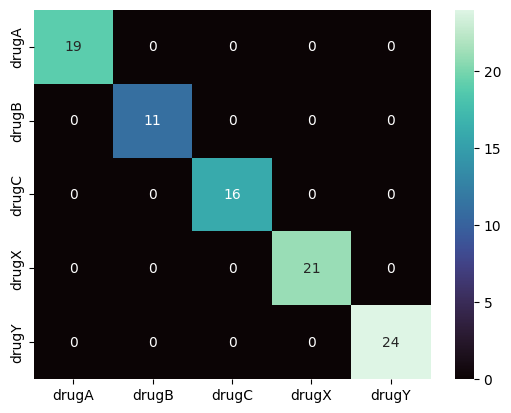

In [42]:
# evaluation
print('accuracy score : ',accuracy_score(y_test, y_pred))
print('\n')
print(classification_report(y_test, y_pred))
print('\n')

sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, cmap = 'mako', xticklabels = class_enc.classes_, yticklabels = class_enc.classes_)
